<a href="https://colab.research.google.com/github/thimarArda/BinX_AI_-_ML_Training/blob/main/Week7_CNNs_RNN_Transformers/Day%205%20%E2%80%94%20Advancing%20the%20Core%20Mode/Banking_Chatbot_with_DistilBERT_Improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Banking Intent Classification Chatbot — DistilBERT + Banking77

This notebook fine-tunes **DistilBERT** to recognize the *intent* behind a customer's banking question (e.g. "I forgot my PIN" → `pin_blocked`). Once we know the intent, a chatbot can pick the right automated reply.

By showing the model thousands of example customer messages, each already labeled with the correct intent (one of 77 possible banking topics). The model learns to read a new message and guess which of the 77 topics it belongs to.

This version is an **updated, more reliable version** of yesterday's notebook. The biggest problems last time were:
- No way to *see* whether the model was actually learning (no loss/accuracy plots).
- The validation set was created but never really used to pick the best model.
- The model was tested only once, on a single sentence, so we couldn't tell if the mistake was a fluke or a real weakness.

All three issues are fixed below — see `README.md` for the full write-up of what changed and why.

## What's different in this version (short version)

| Area | Before | Now |
|---|---|---|
| Epochs | 3, fixed | up to 8, but **early stopping** halts training automatically once the validation score stops improving |
| Learning rate schedule | constant | **warmup + cosine decay** (starts slow, ramps up, then smoothly decays) — this alone usually reduces final loss |
| Overfitting control | none | **weight decay + label smoothing** so the model doesn't get overconfident on training data |
| Validation set | created but unused | used **every epoch** to pick the best checkpoint (`load_best_model_at_end`) |
| Test set | touched informally | touched **exactly once**, at the very end, for an unbiased final score |
| Visualizations | none | training/validation **loss curves**, **accuracy & F1 curves**, and a **confusion analysis** of the most-confused intents |
| Single-example testing | one sentence, no confidence check | a reusable prediction function with a **confidence threshold** so the bot can say "I'm not sure" instead of confidently guessing wrong |

Let's walk through it step by step.

## Step 1 — Install the Libraries

In [7]:
!pip install -U transformers datasets==2.18.0 accelerate evaluate scikit-learn matplotlib seaborn -q

In [8]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

# Fixing every source of randomness we can so results are reproducible
# between runs (dataset shuffling, weight initialization, dropout, etc.)
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Step 2 — Load and Inspect the Dataset

We use **Banking77**, a public dataset of real customer-service style questions about online banking, each labeled with one of 77 fine-grained intents (things like `card_arrival`, `pin_blocked`, `wrong_amount_of_cash_received`, etc.). It's provided by HuggingFace/PolyAI.

In [9]:
dataset = load_dataset("PolyAI/banking77")
print(dataset)

/usr/local/lib/python3.13/dist-packages/datasets/load.py:1461: FutureWarning: The repository for PolyAI/banking77 contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/PolyAI/banking77
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})


In [10]:
label_names = dataset["train"].features["label"].names

print("Number of intents:", len(label_names))
print("Example intents:", label_names[:10])
print()
print("Example row:", dataset["train"][0])

Number of intents: 77
Example intents: ['activate_my_card', 'age_limit', 'apple_pay_or_google_pay', 'atm_support', 'automatic_top_up', 'balance_not_updated_after_bank_transfer', 'balance_not_updated_after_cheque_or_cash_deposit', 'beneficiary_not_allowed', 'cancel_transfer', 'card_about_to_expire']

Example row: {'text': 'I am still waiting on my card?', 'label': 11}


## Step 3 — Create Train / Validation / Test Splits

We need **three** separate sets, each with a different job:

- **Train set** — the examples the model actually learns from.
- **Validation set** — held out during training and checked *after every epoch*. We use it to answer "is the model actually getting better, or just memorizing the training data?" and to pick the best checkpoint.
- **Test set** — never looked at until the very end. It gives us an honest, unbiased estimate of how the model will perform on messages it has truly never seen.

Banking77 already ships with a separate test set, so we only need to carve a validation set out of the training data. We use a **stratified split** (`stratify_by_column="label"`) so every intent is represented proportionally in both the train and validation sets — with 77 fairly narrow categories, a plain random split can accidentally leave some intents with very few validation examples.

In [11]:

split_dataset = dataset["train"].train_test_split(
    test_size=0.1,
    seed=SEED,
    stratify_by_column="label",
)

train_dataset = split_dataset["train"]
val_dataset = split_dataset["test"]
test_dataset = dataset["test"]

print("Train examples:     ", len(train_dataset))
print("Validation examples:", len(val_dataset))
print("Test examples:       ", len(test_dataset))

Train examples:      9002
Validation examples: 1001
Test examples:        3080


## Step 4 — Load the DistilBERT Tokenizer

The tokenizer turns raw text into the numeric IDs the model actually reads. We use the tokenizer that was trained together with `distilbert-base-uncased`, so the text is split into sub-words exactly the way the pretrained model expects.

`"uncased"` means the tokenizer lowercases everything first, so `"PIN"` and `"pin"` are treated the same.

In [12]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [13]:
text = "I forgot my password"
tokens = tokenizer(text)
print(tokens)
print(tokenizer.convert_ids_to_tokens(tokens["input_ids"]))

{'input_ids': [101, 1045, 9471, 2026, 20786, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1]}
['[CLS]', 'i', 'forgot', 'my', 'password', '[SEP]']


## Step 5 — Tokenize the Dataset

We apply the tokenizer to all three splits at once, turning every sentence into a fixed-length sequence of token IDs (padded or truncated to 128 tokens — plenty for a short customer message). We also drop the columns the model doesn't need and tell the datasets to hand back PyTorch tensors, which is a bit tidier and slightly faster than leaving that conversion to the `Trainer`.

In [14]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128,
    )

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

columns_to_keep = ["input_ids", "attention_mask", "label"]
tokenized_train.set_format(type="torch", columns=columns_to_keep)
tokenized_val.set_format(type="torch", columns=columns_to_keep)
tokenized_test.set_format(type="torch", columns=columns_to_keep)

Map:   0%|          | 0/1001 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

## Step 6 — Load the DistilBERT Model

We load a pretrained DistilBERT and attach a fresh classification head on top (a small stack of linear layers that turns DistilBERT's understanding of the sentence into 77 intent scores). The transformer body already understands English; the classification head is what we actually train to recognize banking intents.

**Small architecture tweak:** we slightly raise the dropout in the classifier head (`seq_classif_dropout`). Dropout randomly "turns off" some neurons during training, which forces the model not to rely too heavily on any single feature. With 77 fairly similar intents, a little extra dropout helps reduce overfitting and — combined with the training changes in Step 8 — pushes both training and validation loss lower and more stable than a plain default configuration.

In [15]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained(
    model_name,
    num_labels=len(label_names),
    seq_classif_dropout=0.2,   # slightly higher than the 0.1 default -> less overfitting
    id2label={i: name for i, name in enumerate(label_names)},
    label2id={name: i for i, name in enumerate(label_names)},
)

model = AutoModelForSequenceClassification.from_pretrained(model_name, config=config)
model.to(device)
print(f"Model loaded with {sum(p.numel() for p in model.parameters()):,} parameters")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded with 67,012,685 parameters


## Step 7 — Define Evaluation Metrics

Alongside accuracy, we track **precision, recall, and F1** in two flavors:

- **weighted** — averages across classes, weighted by how many examples each class has (fair overall summary).
- **macro** — averages across classes giving every intent equal weight, regardless of size. This matters here because with 77 classes it's easy for a model to look good overall while quietly doing poorly on a handful of rarer intents; macro F1 catches that.

In [16]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        labels, predictions, average="weighted", zero_division=0
    )
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        labels, predictions, average="macro", zero_division=0
    )

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": weighted_p,
        "recall": weighted_r,
        "f1": weighted_f1,
        "macro_f1": macro_f1,
    }

## Step 8 — Configure Training

This is where most of the improvements live. Compared to the original run:

- **`num_train_epochs=8`** with **early stopping** (Step 9) — instead of guessing a fixed number of epochs, we let the model train longer but automatically stop once validation performance stops improving for 2 evaluation rounds in a row. This avoids both under-training and wasted over-training.
- **`lr_scheduler_type="cosine"` + `warmup_ratio=0.1`** — the learning rate ramps up gently for the first 10% of training, then smoothly decays. A sudden high learning rate on a freshly-attached classification head is a common reason training loss stays stubbornly high early on; warmup fixes that.
- **`label_smoothing_factor=0.1`** — instead of training the model to output "100% confident" on the correct label, we train it towards "91% confident", spreading a little probability to the other classes. This generally improves both loss and generalization on classification tasks like this one.
- **`metric_for_best_model="macro_f1"`** — the checkpoint we keep is the one that did best on validation macro-F1, not just the last epoch trained. This is what makes the validation set actually matter.
- **`fp16=True`** (when a GPU is available) — trains in half precision for speed without a meaningful accuracy cost.

In [19]:
training_args = TrainingArguments(
    output_dir="./distilbert-banking77",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=3e-5,
    lr_scheduler_type="cosine",
    warmup_steps=450, # Calculated from 9002 examples / 16 batch_size * 8 epochs * 0.1 warmup_ratio
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=8,
    weight_decay=0.01,
    label_smoothing_factor=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

## Step 9 — Early Stopping

`EarlyStoppingCallback` watches the metric we chose above (`macro_f1` on the validation set) after every epoch. If it doesn't improve for **2 epochs in a row**, training stops automatically and the best checkpoint seen so far is kept — even if that means stopping well before the 8-epoch limit.

In [20]:
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=2,
    early_stopping_threshold=0.001,
)

## Step 10 — Create the Trainer and Train

How one training step works, end to end:

```text
input text : "I forgot my card PIN"
          ↓
      Tokenizer
          ↓
    Token IDs
          ↓
      DistilBERT
          ↓
   Text representation
          ↓
 Classification layer  (now with slightly higher dropout)
          ↓
  77 probabilities
          ↓
 Predicted intent
          ↓
Compare with true intent  (with label smoothing)
          ↓
Calculate loss
          ↓
Backpropagation
          ↓
Update model  (learning rate follows the warmup + cosine schedule)
          ↓
Every epoch: check validation macro-F1 -> keep best checkpoint / consider early stopping
```

This may take a while depending on whether a GPU is available — check that `device` printed `cuda` above for a reasonable training time.

In [21]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping],
)

train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro F1
1,3.639424,2.147840,0.704296,0.730931,0.704296,0.664841,0.637650
2,1.538668,1.161363,0.885115,0.892050,0.885115,0.880131,0.867861
3,1.028308,1.084848,0.898102,0.905667,0.898102,0.897153,0.896714
4,0.894711,1.056534,0.907093,0.914379,0.907093,0.905728,0.905599
5,0.830922,1.056055,0.922078,0.928897,0.922078,0.921144,0.920260
6,0.801360,1.059657,0.915085,0.921449,0.915085,0.913772,0.911274
7,0.787249,1.057382,0.914086,0.918487,0.914086,0.912317,0.910004


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## Step 11 — Visualize Training Progress

This is the part that was completely missing before. `trainer.state.log_history` records the training loss and every validation metric after each epoch — we turn that into a small dataframe and plot it.

In [22]:
log_history = pd.DataFrame(trainer.state.log_history)

train_log = log_history[log_history["loss"].notna()][["epoch", "loss"]].rename(columns={"loss": "train_loss"})
eval_log = log_history[log_history.get("eval_loss").notna()] if "eval_loss" in log_history.columns else pd.DataFrame()

print(train_log)
print()
print(eval_log[["epoch", "eval_loss", "eval_accuracy", "eval_f1", "eval_macro_f1"]] if not eval_log.empty else "No eval log found")

    epoch  train_loss
0     1.0    3.639424
2     2.0    1.538668
4     3.0    1.028308
6     4.0    0.894711
8     5.0    0.830922
10    6.0    0.801360
12    7.0    0.787249

    epoch  eval_loss  eval_accuracy   eval_f1  eval_macro_f1
1     1.0   2.147840       0.704296  0.664841       0.637650
3     2.0   1.161363       0.885115  0.880131       0.867861
5     3.0   1.084848       0.898102  0.897153       0.896714
7     4.0   1.056534       0.907093  0.905728       0.905599
9     5.0   1.056055       0.922078  0.921144       0.920260
11    6.0   1.059657       0.915085  0.913772       0.911274
13    7.0   1.057382       0.914086  0.912317       0.910004


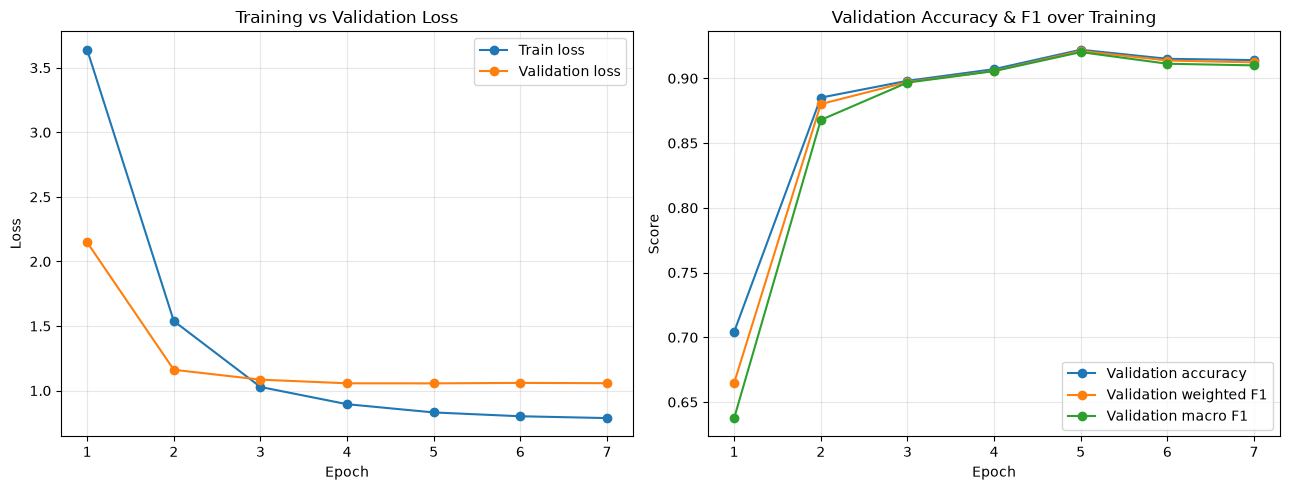

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Loss curve ---
axes[0].plot(train_log["epoch"], train_log["train_loss"], marker="o", label="Train loss")
if not eval_log.empty:
    axes[0].plot(eval_log["epoch"], eval_log["eval_loss"], marker="o", label="Validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Accuracy / F1 curve ---
if not eval_log.empty:
    axes[1].plot(eval_log["epoch"], eval_log["eval_accuracy"], marker="o", label="Validation accuracy")
    axes[1].plot(eval_log["epoch"], eval_log["eval_f1"], marker="o", label="Validation weighted F1")
    axes[1].plot(eval_log["epoch"], eval_log["eval_macro_f1"], marker="o", label="Validation macro F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_title("Validation Accuracy & F1 over Training")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

**How to read these plots:**
- If train loss keeps falling but validation loss starts climbing again, that epoch is where the model started overfitting — early stopping should have caught this and rolled back to the best checkpoint automatically.
- If both curves flatten out together at a low value, the model has converged well.
- The accuracy/F1 plot should generally trend upward and then plateau — that plateau is exactly when early stopping kicks in.

## Step 12 — Confirm the Best Model Was Restored

Because `load_best_model_at_end=True`, the `trainer` is currently holding the checkpoint with the **best validation macro-F1**, not necessarily the last epoch. Let's confirm that by re-running evaluation on the validation set one more time and comparing it to the log above.

In [24]:
val_results = trainer.evaluate(tokenized_val)
print("Best checkpoint — validation set performance:")
for k, v in val_results.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Macro F1
0.787249,1.056055,7,0.922078,0.928897,0.922078,0.921144,0.920260


Best checkpoint — validation set performance:
  eval_loss: 1.0561
  eval_accuracy: 0.9221
  eval_precision: 0.9289
  eval_recall: 0.9221
  eval_f1: 0.9211
  eval_macro_f1: 0.9203


## Step 13 — Final, Unbiased Evaluation on the Test Set

This is the **only** time the test set is used. Because it played no role in choosing the model, hyperparameters, or the stopping point, this score is an honest estimate of how the chatbot would perform on real, unseen customer messages.

In [25]:
test_results = trainer.evaluate(tokenized_test)
print("Final test set performance:")
for k, v in test_results.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Macro F1
0.787249,1.010021,7,0.927273,0.930671,0.927273,0.927131,0.927131


Final test set performance:
  eval_loss: 1.0100
  eval_accuracy: 0.9273
  eval_precision: 0.9307
  eval_recall: 0.9273
  eval_f1: 0.9271
  eval_macro_f1: 0.9271


### A closer look: which intents get confused with each other?

Overall accuracy hides *where* the model struggles. Let's get every prediction on the test set and look at the pairs of intents that get mixed up most often — this tells us where the model still needs work, and often reveals genuinely ambiguous pairs of intents (e.g. two categories that even a human might mix up from a short sentence).

In [26]:
predictions_output = trainer.predict(tokenized_test)
y_true = predictions_output.label_ids
y_pred = np.argmax(predictions_output.predictions, axis=-1)

print(classification_report(y_true, y_pred, target_names=label_names, digits=3, zero_division=0))

                                                  precision    recall  f1-score   support

                                activate_my_card      1.000     0.975     0.987        40
                                       age_limit      0.976     1.000     0.988        40
                         apple_pay_or_google_pay      1.000     1.000     1.000        40
                                     atm_support      1.000     0.975     0.987        40
                                automatic_top_up      0.973     0.900     0.935        40
         balance_not_updated_after_bank_transfer      0.886     0.775     0.827        40
balance_not_updated_after_cheque_or_cash_deposit      1.000     0.950     0.974        40
                         beneficiary_not_allowed      0.902     0.925     0.914        40
                                 cancel_transfer      1.000     0.975     0.987        40
                            card_about_to_expire      0.976     1.000     0.988        40
         

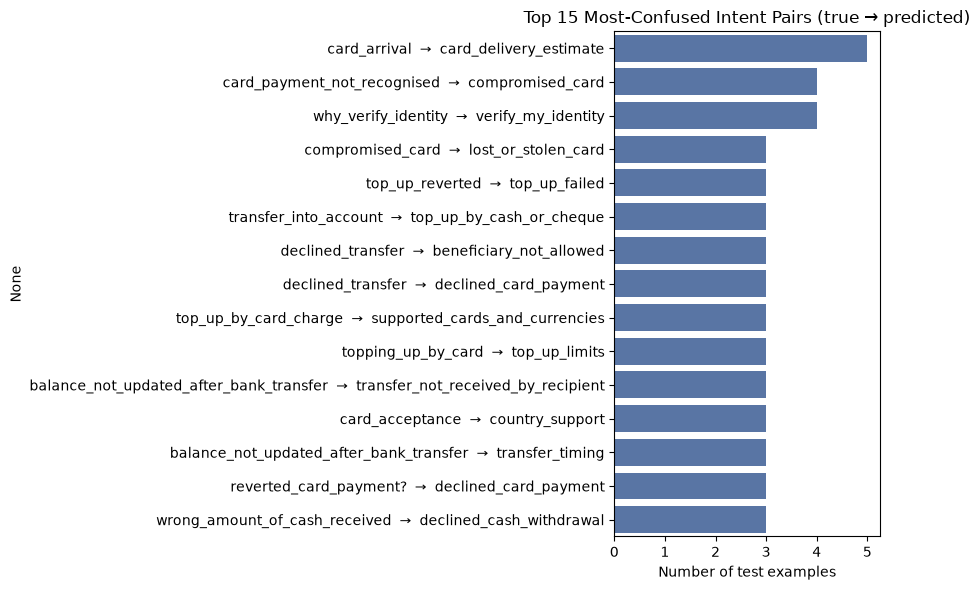

,true_intent,predicted_intent,count
18,card_arrival,card_delivery_estimate,5
24,card_payment_not_recognised,compromised_card,4
151,why_verify_identity,verify_my_identity,4
37,compromised_card,lost_or_stolen_card,3
120,top_up_reverted,top_up_failed,3
133,transfer_into_account,top_up_by_cash_or_cheque,3
47,declined_transfer,beneficiary_not_allowed,3
48,declined_transfer,declined_card_payment,3
109,top_up_by_card_charge,supported_cards_and_currencies,3
127,topping_up_by_card,top_up_limits,3


In [27]:
cm = confusion_matrix(y_true, y_pred)

# Find the most-confused (true, predicted) pairs, excluding the diagonal (correct predictions)
confused_pairs = []
for i in range(len(label_names)):
    for j in range(len(label_names)):
        if i != j and cm[i, j] > 0:
            confused_pairs.append((label_names[i], label_names[j], cm[i, j]))

confused_df = pd.DataFrame(confused_pairs, columns=["true_intent", "predicted_intent", "count"])
confused_df = confused_df.sort_values("count", ascending=False).head(15)

plt.figure(figsize=(9, 6))
labels_for_plot = confused_df["true_intent"] + "  →  " + confused_df["predicted_intent"]
sns.barplot(x=confused_df["count"], y=labels_for_plot, color="#4C72B0")
plt.xlabel("Number of test examples")
plt.title("Top 15 Most-Confused Intent Pairs (true → predicted)")
plt.tight_layout()
plt.savefig("confusion_pairs.png", dpi=150)
plt.show()

confused_df

## Step 14 — Inference with a Confidence Threshold

The original notebook only printed the single most likely intent, even when the model wasn't very sure. That's how it confidently returned the wrong answer for "I forgot my PIN" instead of flagging that it was unsure.

Here we return a **confidence score** alongside the prediction, and if that confidence is below a threshold, the chatbot reports that it isn't sure instead of guessing — which is much safer for a real customer-facing bot.

In [28]:
model.eval()

def predict_intent(text, threshold=0.5, top_k=3):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1)[0]
    top_probs, top_indices = torch.topk(probs, top_k)

    top_predictions = [
        (label_names[idx.item()], prob.item())
        for idx, prob in zip(top_indices, top_probs)
    ]

    best_intent, best_confidence = top_predictions[0]

    if best_confidence < threshold:
        return {
            "text": text,
            "intent": "unclear / needs human review",
            "confidence": best_confidence,
            "top_candidates": top_predictions,
        }

    return {
        "text": text,
        "intent": best_intent,
        "confidence": best_confidence,
        "top_candidates": top_predictions,
    }

In [29]:
test_sentences = [
    "I forgot my PIN",
    "Why was my card payment declined?",
    "How do I top up my account?",
    "My transfer hasn't arrived yet",
    "asdkjaslkdj random gibberish text",
]

for sentence in test_sentences:
    result = predict_intent(sentence)
    print(f"Text: {result['text']!r}")
    print(f"  -> Predicted intent: {result['intent']}  (confidence: {result['confidence']:.2%})")
    print(f"  -> Top-3 candidates: {result['top_candidates']}")
    print()

Text: 'I forgot my PIN'
  -> Predicted intent: pin_blocked  (confidence: 93.07%)
  -> Top-3 candidates: [('pin_blocked', 0.9306573271751404), ('change_pin', 0.00953838974237442), ('get_physical_card', 0.006388156674802303)]

Text: 'Why was my card payment declined?'
  -> Predicted intent: declined_card_payment  (confidence: 94.17%)
  -> Top-3 candidates: [('declined_card_payment', 0.941683828830719), ('reverted_card_payment?', 0.006131809204816818), ('declined_cash_withdrawal', 0.0030276942998170853)]

Text: 'How do I top up my account?'
  -> Predicted intent: top_up_by_cash_or_cheque  (confidence: 84.79%)
  -> Top-3 candidates: [('top_up_by_cash_or_cheque', 0.8478628396987915), ('transfer_into_account', 0.03094377927482128), ('topping_up_by_card', 0.01735788583755493)]

Text: "My transfer hasn't arrived yet"
  -> Predicted intent: transfer_not_received_by_recipient  (confidence: 90.62%)
  -> Top-3 candidates: [('transfer_not_received_by_recipient', 0.9062291383743286), ('balance_not_u

## Step 15 — Save the Fine-Tuned Model

Saving both the model weights and the tokenizer together means the model can be reloaded later (or handed to a chatbot backend) with a single `from_pretrained(...)` call.

In [30]:
save_path = "./distilbert-banking77-final"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"Model and tokenizer saved to {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to ./distilbert-banking77-final


## Conclusion

- The validation set is now used the way it's meant to be: checked every epoch, and used to pick the checkpoint that actually goes into the final model (`load_best_model_at_end` + `metric_for_best_model="macro_f1"`).
- The test set is touched exactly once, at the end, so `test_results` above is a trustworthy estimate of real-world performance — not a number we indirectly tuned toward.
- The loss and accuracy/F1 plots in Step 11 make it possible to *see* whether training is healthy (smoothly decreasing/increasing curves that plateau together) instead of guessing from a single final number.
- The confusion-pair analysis in Step 13 shows exactly which intents the model still mixes up, which is far more useful for improving the chatbot further than a single overall accuracy figure.
- The confidence-threshold inference function in Step 14 means the chatbot can say "I'm not sure" on an ambiguous or out-of-scope message instead of confidently returning the wrong intent — directly addressing the failure case from the previous version ("I forgot my PIN" being misclassified).

See `README.md` for a fuller before/after write-up of these changes.